In [ ]:
# p: Non Seasonal AR
# d: Non seasonal diff
# q: Non seasonal MA

#P: Seasonal AR
#D: Seasonal diff
#Q: Seasonal MA

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


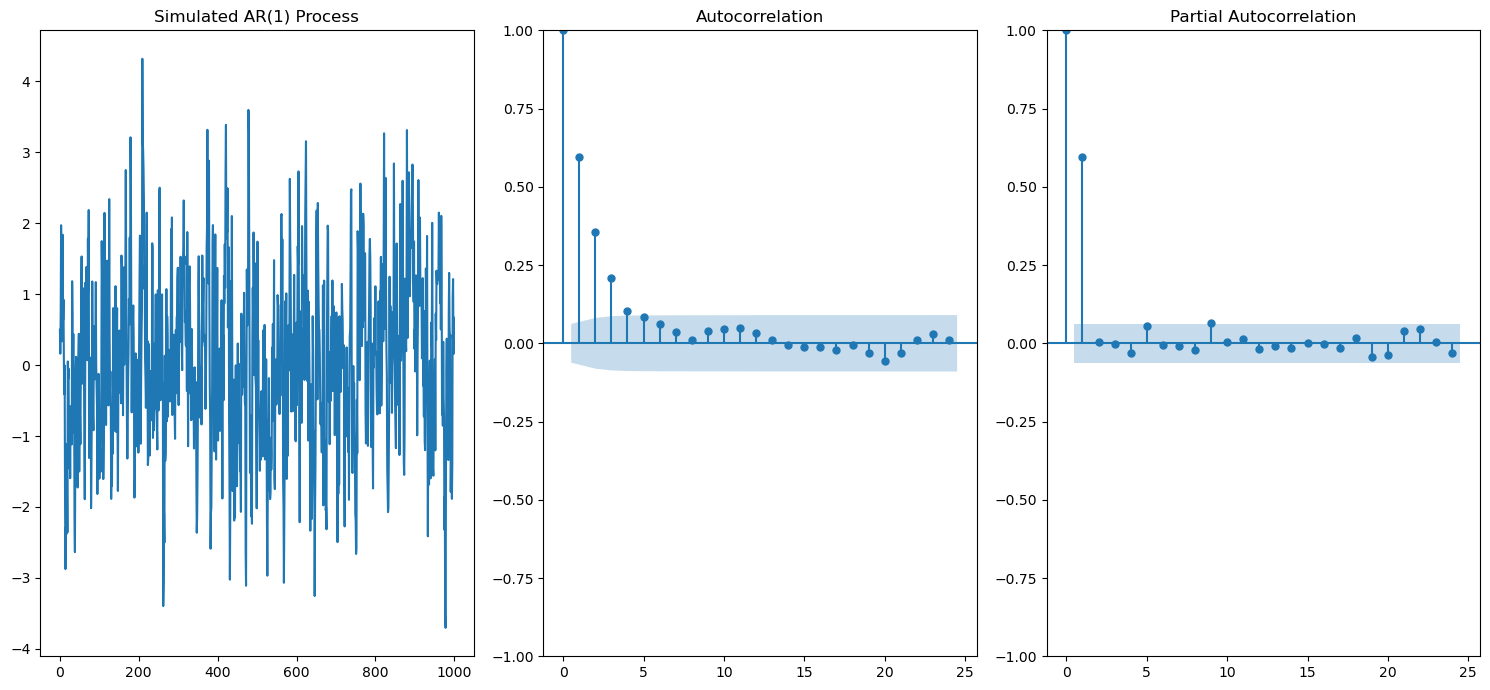

In [16]:
#2.1
# 1. Define parameters
phi_1 = 0.6
ar = np.array([1, -phi_1]) # AR polynomial: [1, -0.6]
ma = np.array([1])         # MA polynomial: [1]

# 2. Simulate the process (e.g., 300 observations)
np.random.seed(42) # For reproducibility
y = arma_generate_sample(ar, ma, nsample=1000)

# 3. Plotting (as requested in instructions)
fig, axes = plt.subplots(1, 3, figsize=(15,7))

# Time Series Plot
axes[0].plot(y)
axes[0].set_title("Simulated AR(1) Process")

# ACF Plot (up to lag 24 to see seasonal behavior)
plot_acf(y, lags=24, ax=axes[1])

# PACF Plot
plot_pacf(y, lags=24, ax=axes[2])

plt.tight_layout()
plt.savefig("2.1.jpg")
plt.show()

The AR(1) model can be described as $Y_t = 0.6Y_{t-1} + \epsilon_t$

The ACF shows geometric decay, starting at 0.6 for Lag 1. This indicates 60% autocorrelation between consecutive steps. The PACF also shows 0.6 at Lag 1 but cuts off at Lag 2. This is because the intermediate information at Lag 1 was removed, leaving only white noise.

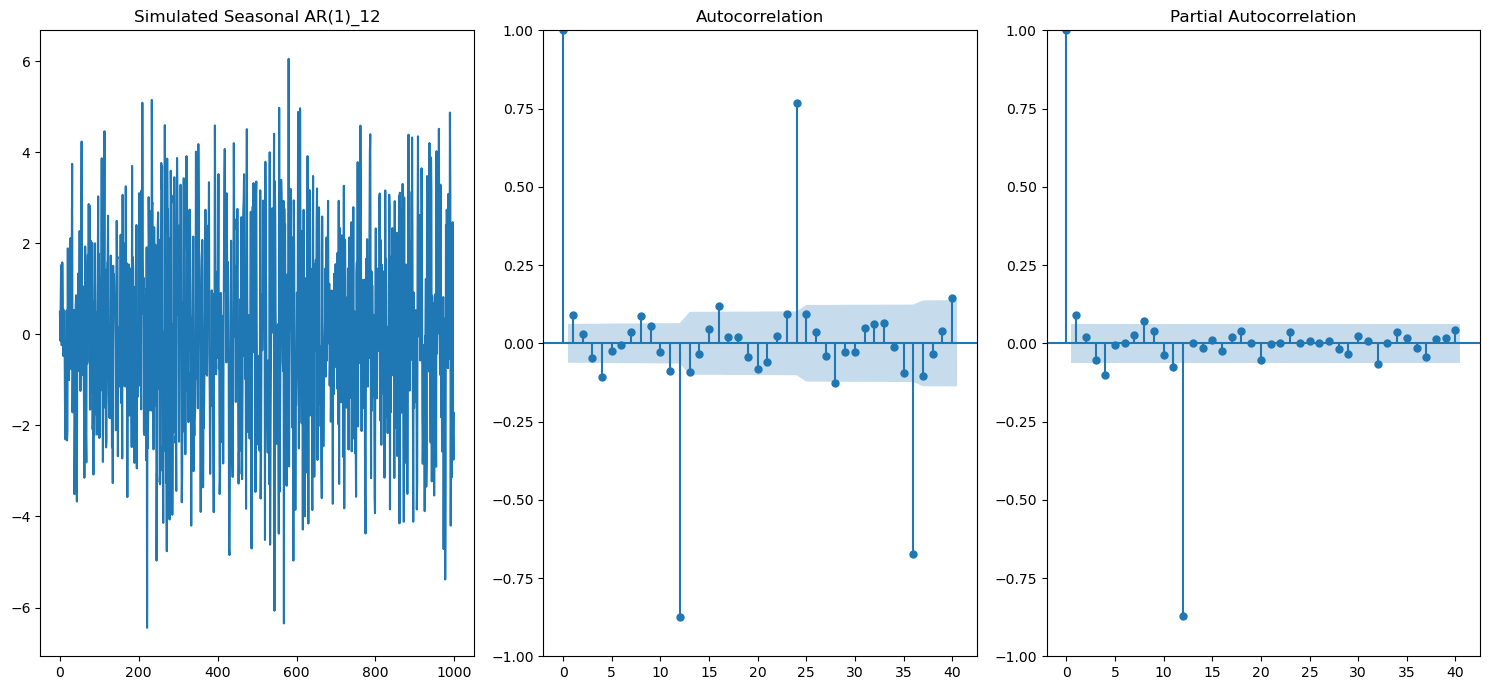

In [17]:

# Model: (0,0,0) x (1,0,0)_12 with Phi_1 = -0.9
phi_1 = -0.9
# Create the AR polynomial: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -(-0.9)]
ar = np.zeros(13)
ar[0] = 1
ar[12] = -phi_1  # Sign is flipped for arma_generate_sample

ma = np.array([1])

# 2. Simulate
np.random.seed(42)
y = arma_generate_sample(ar, ma, nsample=1000)

# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

axes[0].plot(y)
axes[0].set_title("Simulated Seasonal AR(1)_12")

# Look at 50 lags to see the seasonal spikes at 12, 24, 36, 48
plot_acf(y, lags=40, ax=axes[1])
plot_pacf(y, lags=40, ax=axes[2])

plt.tight_layout()
plt.savefig("2.2.jpg")
plt.show()


The operator notation is  $(1 - \Phi_1 B^{12}) Y_t = \epsilon_t$

Isolating $Y_t$ and inserting the value $\Phi_1 = -0.9$  AR(1) model gives

 $Y_t = -0.9Y_{t-12} + \epsilon_t$

The AR(1) model is seasonal where the seasonal AR term is order 1. In the ACF plot, we see that there is oscillating autocorrelation at lag 12, lag 24 and lag 36. For the PACF model, also see negative correlation for lag 12 since phi_1 = -0.9. The other autocorrelations are in PACF are white noise.

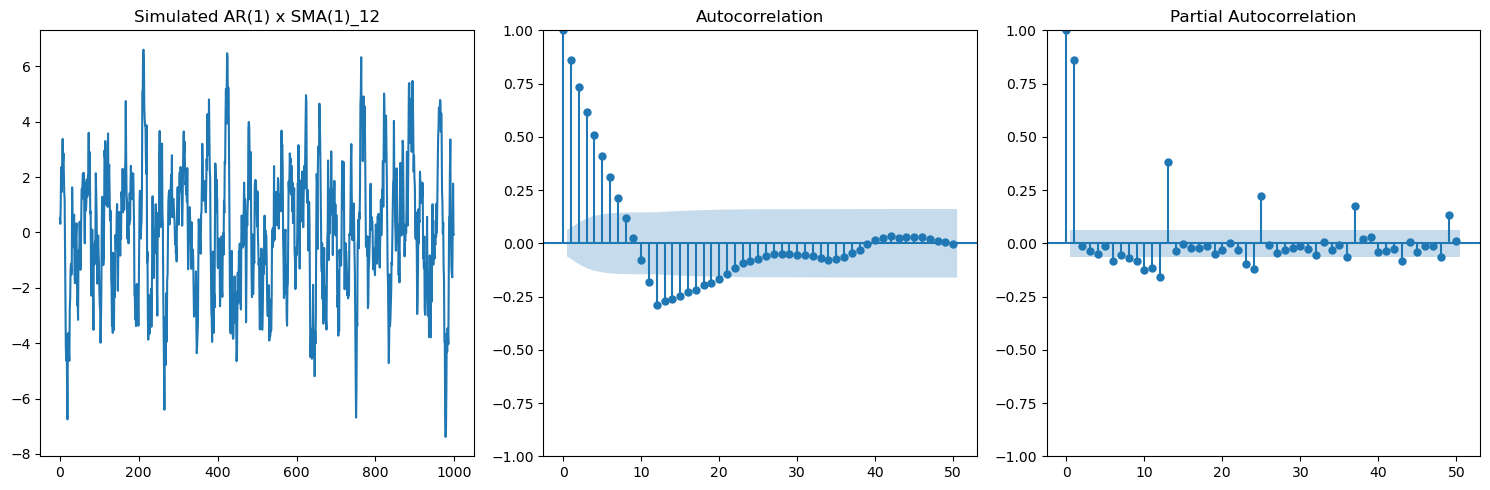

In [18]:

# Model: (1,0,0) x (0,0,1)_12 
# Parameters: phi_1 = 0.9, Theta_1 = -0.7
phi_1 = 0.9
Theta_1 = -0.7

# AR polynomial: (1 - 0.9B) -> [1, -0.9]
ar = np.array([1, -phi_1])
# MA polynomial: (1 - 0.7B^12) -> [1, 0, 0, ..., -0.7]
ma = np.zeros(13)
ma[0] = 1
ma[12] = Theta_1  # In statsmodels, MA signs usually match the operator form
# 2. Simulate
np.random.seed(42)
y = arma_generate_sample(ar, ma, nsample=1000)
# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(y)
axes[0].set_title("Simulated AR(1) x SMA(1)_12")

plot_acf(y, lags=50, ax=axes[1])
plot_pacf(y, lags=50, ax=axes[2])

plt.tight_layout()
plt.savefig("2.3.jpg")
plt.show()

The operator notation is 

 $(1 - \phi_1 B) Y_t = (1 + \Theta_1 B^{12}) \epsilon_t$


Isolating $Y_t$

$Y_t = \frac{(1 - 0.7B^{12})}{(1 - 0.9B)} \epsilon_t$

Inserting the values of $\phi_1$ and $\Theta_1$ and doing polynomial expansion gives:

$Y_t = 0.9 Y_{t-1} + \epsilon_t - 0.7 \epsilon_{t-12} + 0.63 \epsilon_{t-13}$

This model is a multiplicative combination of a non-seasonal AR(1) and a seasonal MA(1) process. In the ACF plot, we see a slow exponential decay caused by the AR term ($0.9Y_{t-1}$), with a distinct spike at lag 12 due to the seasonal error term. For the PACF, there is a significant positive correlation at lag 1, followed by a decaying seasonal pattern at lags 12, 24, and 36. The remaining lags fall within the bounds of white noise.

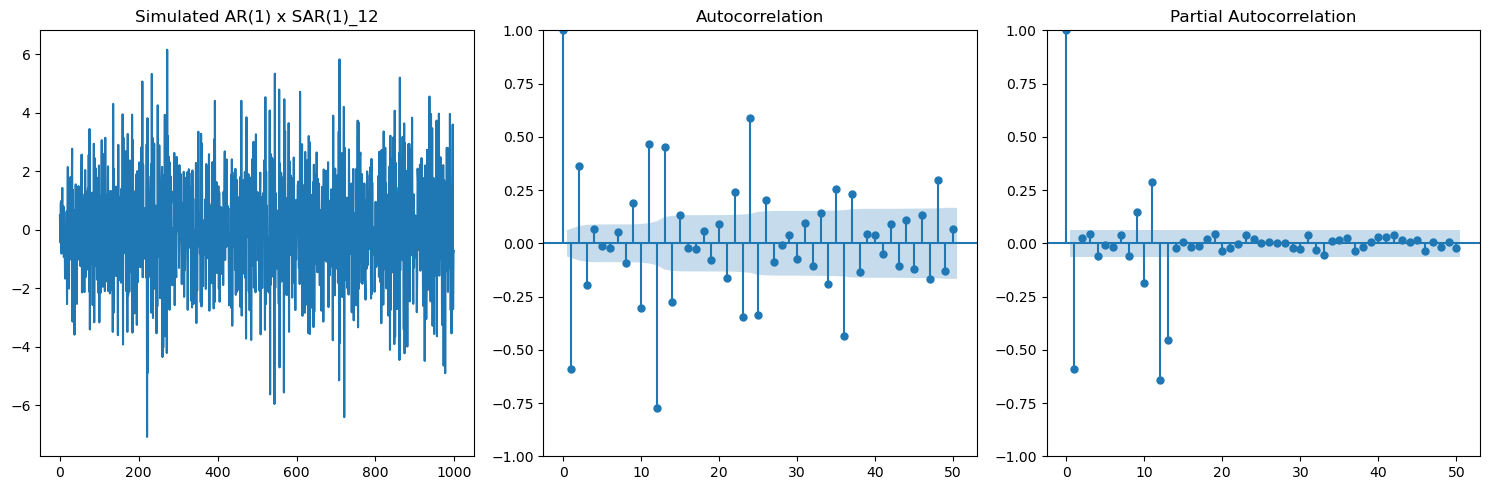

In [19]:
# Model 2.4: (1,0,0) x (1,0,0)_12
phi_1 = -0.6
Phi_1 = -0.8

# Expanded AR polynomial: [1, 0.6, 0, ..., 0.8, 0.48]
# Note: Signs in the 'ar' array match the operator form (1 + 0.6B + 0.8B^12 + 0.48B^13)
ar = np.zeros(14)
ar[0] = 1
ar[1] = -phi_1          # +0.6
ar[12] = -Phi_1         # +0.8
ar[13] = phi_1 * Phi_1  # +0.48

ma = np.array([1])

# Simulate
np.random.seed(42)
y24 = arma_generate_sample(ar, ma, nsample=1000)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(y24)
axes[0].set_title("Simulated AR(1) x SAR(1)_12")
plot_acf(y24, lags=50, ax=axes[1])
plot_pacf(y24, lags=50, ax=axes[2])
plt.tight_layout()
plt.savefig("2.4.jpg")
plt.show()


The operator notation is:

$(1 - \phi_1 B)(1 - \Phi_1 B^{12}) Y_t = \epsilon_t$ (1)

Expanding the brackets gives 

$(1 - \Phi_1 B^{12} - \phi_1 B + \phi_1 \Phi_1 B^{13}) Y_t = \epsilon_t$ (2)

Finally, we isolate $Y_t$

$Y_t = \phi_1 Y_{t-1} + \Phi_1 Y_{t-12} - (\phi_1 \Phi_1) Y_{t-13} + \epsilon_t$ (3)

The model for 2.4 is described by the equation $Y_t = -0.6Y_{t-1} - 0.8Y_{t-12} - 0.48Y_{t-13} + \epsilon_t$.

This is a multiplicative seasonal AR model where both the non-seasonal and seasonal parts are order 1. In the ACF plot, we see an oscillating decay because both AR parameters are negative, causing the correlation to change signs at each lag. For the PACF, we see significant negative spikes at lag 1 and lag 12, followed by a smaller interaction spike at lag 13. The PACF then cuts off for the remaining lags, which is typical for a purely autoregressive process.

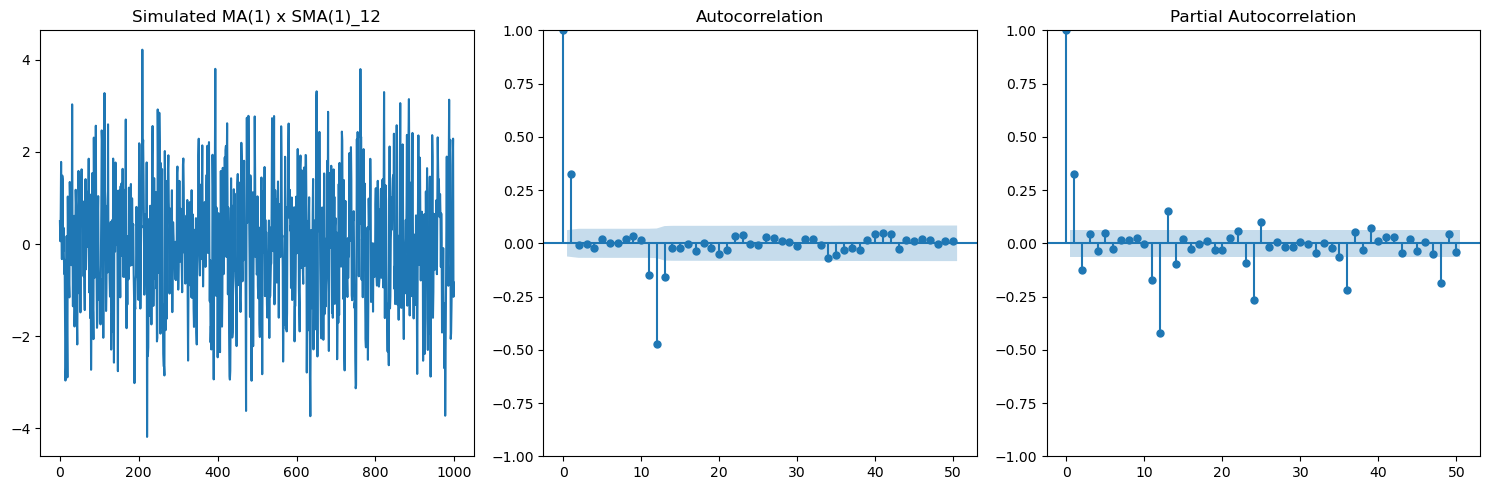

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Model 2.5: (0,0,1) x (0,0,1)_12
theta_1 = 0.4
Theta_1 = -0.8

# AR polynomial is just [1] because there are no AR terms
ar = np.array([1])

# Expanded MA polynomial: [1, 0.4, 0, ..., -0.8, -0.32]
# The form is: 1 + theta_1*B + Theta_1*B^12 + (theta_1 * Theta_1)*B^13
ma = np.zeros(14)
ma[0] = 1
ma[1] = theta_1           # 0.4
ma[12] = Theta_1          # -0.8
ma[13] = theta_1 * Theta_1 # -0.32 (0.4 * -0.8)

# Simulate
np.random.seed(42)
y25 = arma_generate_sample(ar, ma, nsample=1000)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(y25)
axes[0].set_title("Simulated MA(1) x SMA(1)_12")

# ACF is the key diagnostic for MA models
plot_acf(y25, lags=50, ax=axes[1])
plot_pacf(y25, lags=50, ax=axes[2])

plt.tight_layout()
plt.savefig("2.5.jpg")
plt.show()

The operator form of the model $(0,0,1) \times (0,0,1)_{12}$ with $\theta_1 = 0.4$ and $\Theta_1 = -0.8$ is

$$Y_t = (1 + \theta_1 B)(1 + \Theta_1 B^{12})\epsilon_t$$

Expanding the brackets gives: 

$Y_t = (1 + \theta_1 B + \Theta_1 B^{12} + \theta_1 \Theta_1 B^{13})\epsilon_t$

Now we insert the values of  $\theta_1$ and $\Theta_1$

$Y_t = (\epsilon_t  + 0.4B - 0.8B^{12} - 0.32B^{13})\epsilon_t$

Finally, we convert the formula to the difference equation form by replacing the backshift operators with time-lagged values of the series

$Y_t = \epsilon_t + 0.4 \epsilon_{t-1} - 0.8 \dot \epsilon_{t-12} - 0.32 \dot \epsilon_{t-13}$

The ACF shows a significant positive correlation at Lag 1 and a strong negative correlation at Lag 12, directly reflecting the parameters $\theta_1 = 0.4$ and $\Theta_1 = -0.8$. We also observe small interaction spikes at Lags 11 and 13, after which the ACF cuts off. The PACF does not cut off,instead, it exhibits a geometric decay toward zero. While the non-seasonal correlation decays quickly, we see significant recurring negative spikes at the seasonal multiples (Lags 12, 24, and 36), confirming the presence of a seasonal moving average component.



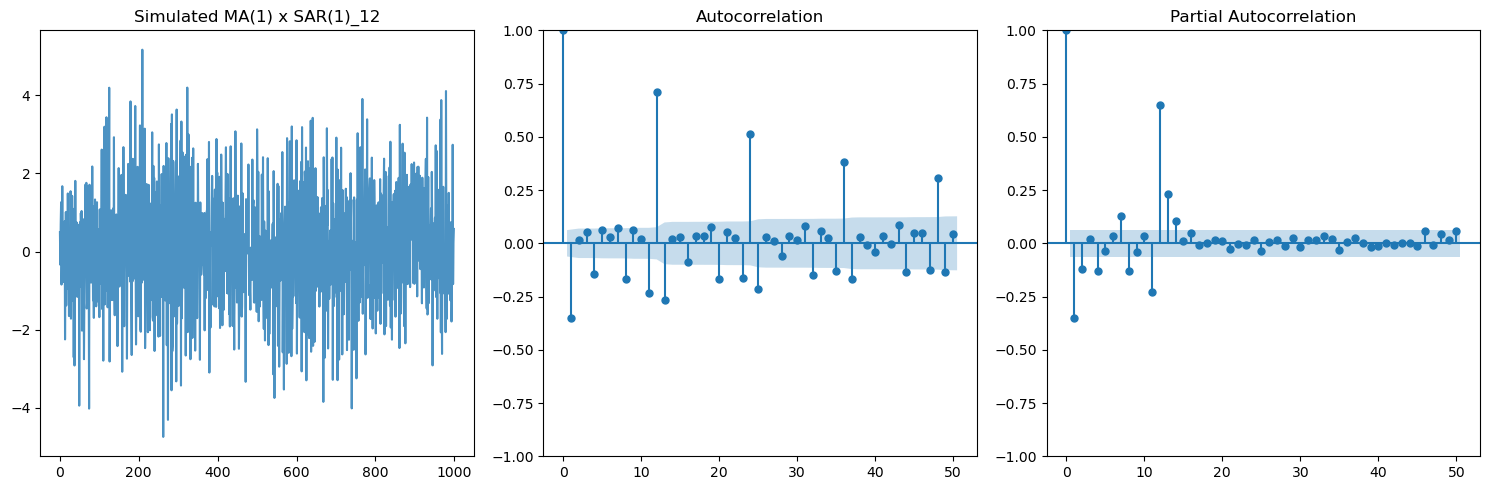

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Model 2.6: (0,0,1) x (1,0,0)_12
theta_1 = -0.4

Phi_1 = 0.7

# AR polynomial: (1 - Phi_1 * B^12)
# Statsmodels format: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -Phi_1]
ar = np.zeros(13)
ar[0] = 1
ar[12] = -Phi_1  # Opposite sign for AR terms in statsmodels

# MA polynomial: (1 + theta_1 * B)

# Statsmodels format: [1, theta_1]
ma = np.zeros(2)
ma[0] = 1
ma[1] = theta_1

# Simulate
np.random.seed(42)
y26 = arma_generate_sample(ar, ma, nsample=1000)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Time Series Plot
axes[0].plot(y26, alpha=0.8)
axes[0].set_title("Simulated MA(1) x SAR(1)_12")

# 2. ACF Plot (Should taper/decay because of the AR component)
plot_acf(y26, lags=50, ax=axes[1])

# 3. PACF Plot (Should cut off after the seasonal/non-seasonal lags)
plot_pacf(y26, lags=50, ax=axes[2])

plt.tight_layout()
plt.savefig("2.6.jpg")
plt.show()

The operator form of the model $(0,0,1) \times (1,0,0)_{12}$ with $\theta_1 = -0.4$ and $\Phi_1 = 0.7$ is:$$(1 - \Phi_1 B^{12})Y_t = (1 + \theta_1 B)\epsilon_t$$Expanding the brackets and isolating $Y_t$ gives:$$Y_t = \Phi_1 B^{12} Y_t + \epsilon_t + \theta_1 B \epsilon_t$$Now we insert the values of $\theta_1 = -0.4$ and $\Phi_1 = 0.7$:$$Y_t = 0.7 B^{12} Y_t + \epsilon_t - 0.4 B \epsilon_t$$Finally, we convert the formula to the difference equation form by replacing the backshift operators with time-lagged values

$Y_t = 0.7 Y_{t-12} + \epsilon_t - 0.4 \epsilon_{t-1}$

The ACF  exhibits a geometric decay across seasonal multiples (Lags 12, 24, 36, etc.) due to the seasonal autoregressive part  $\Phi_1$ component. We observe a significant negative spike at Lag 1, directly reflecting the parameter $\theta_1 = -0.4$, and secondary interaction spikes around the seasonal lags as the correlation structure tapers off toward zero.

The PACF shows a significant negative spike at Lag 1 and a significant positive spike at Lag 12. Because the non-seasonal part is a moving average (MA) and the seasonal part is autoregressive (AR), the PACF will show a "clean" cut-off after Lag 12 for the seasonal component, while the non-seasonal component (Lag 1) will show geometric decay in the PACF. This confirms the presence of a non-seasonal moving average combined with a seasonal autoregressive structure.